
## NIO initial Points Density maps


In [1]:

# ============================================================
# Lorenz NIO Visual Discovery Paper
#
# Step 1 : Load NIO Results
# Step 2 : Summary Statistics
# Step 3 : 3D State Space Plot
# Step 4 : Projection Plots
# Step 5 : Sensitivity Density Maps
#
# Assumes:
#   nio_tumor_max.csv
#   nio_tumor_min.csv
#
# Uses:
#   300-step horizon only
#
# Ricardo Calix
# ============================================================


In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde


In [3]:

# ============================================================
# CONFIGURATION
# ============================================================

## MAX_FILE = "nio_tumor_max.csv"
## MIN_FILE = "nio_tumor_min.csv"

MAX_FILE = "nio_tumor_max.csv"


###########################################

random_flag = False        ## Change Only this


if random_flag:
    MIN_FILE    = "random_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_tumor_min.csv"
    name_output = "Min"


###########################################

HORIZON = 300


In [4]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [5]:

max_df


,Time_steps,point_id,T0,I0,C0
0,300,0,94.363075,1.008301,1.012808
1,300,1,94.355000,1.008443,1.015140
2,300,2,94.338260,1.008205,1.011293
3,300,3,94.363480,1.008082,1.019414
4,300,4,94.337350,1.007756,1.022836
...,...,...,...,...,...
3995,1300,995,1.002036,1.002354,1.008119
3996,1300,996,1.002685,1.002980,1.001838
3997,1300,997,1.002261,1.003928,1.004407
3998,1300,998,1.001121,1.008635,1.005036


In [6]:

min_df


,Time_steps,point_id,T0,I0,C0
0,300,0,1.130639,95.297280,96.604550
1,300,1,99.361465,98.961655,99.208115
2,300,2,98.103325,96.059840,99.637405
3,300,3,1.055825,97.566826,96.828310
4,300,4,99.754196,99.810930,99.592390
...,...,...,...,...,...
3995,1300,995,86.123400,72.417564,67.186940
3996,1300,996,79.084670,92.244415,76.388190
3997,1300,997,73.070145,82.194460,73.420160
3998,1300,998,85.901024,98.192200,79.995255


In [7]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [8]:

time_col


'Time_steps'

In [9]:

max_data = max_df[max_df[time_col] == HORIZON].copy()



In [10]:

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()    




In [11]:

max_data


,Time_steps,point_id,T0,I0,C0
0,300,0,94.363075,1.008301,1.012808
1,300,1,94.355000,1.008443,1.015140
2,300,2,94.338260,1.008205,1.011293
3,300,3,94.363480,1.008082,1.019414
4,300,4,94.337350,1.007756,1.022836
...,...,...,...,...,...
995,300,995,94.360620,1.007956,1.017016
996,300,996,94.380450,1.008049,1.001357
997,300,997,94.355540,1.008237,1.005542
998,300,998,94.348720,1.008216,1.016559


In [12]:

min_data


,Time_steps,point_id,T0,I0,C0
0,300,0,1.130639,95.297280,96.604550
1,300,1,99.361465,98.961655,99.208115
2,300,2,98.103325,96.059840,99.637405
3,300,3,1.055825,97.566826,96.828310
4,300,4,99.754196,99.810930,99.592390
...,...,...,...,...,...
995,300,995,99.760360,99.803764,99.578520
996,300,996,99.076230,98.409950,98.954796
997,300,997,99.745470,99.015320,99.047220
998,300,998,1.141947,91.229820,92.139710


In [13]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000




## SUMMARY STATISTICS


In [14]:

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)




SUMMARY STATISTICS


In [15]:

def summarize(df, label):

    stats = pd.DataFrame({
        "Mean": df[["T0","I0","C0"]].mean(),
        "Std":  df[["T0","I0","C0"]].std(),
        "Min":  df[["T0","I0","C0"]].min(),
        "Max":  df[["T0","I0","C0"]].max()
    })

    print("\n")
    print(label)
    print("-"*50)
    print(stats)


In [16]:

summarize(max_data, "MAX-SENSITIVE")




MAX-SENSITIVE
--------------------------------------------------
         Mean       Std       Min        Max
T0  94.364704  0.017472  94.15167  94.472290
I0   1.007952  0.000651   1.00307   1.008974
C0   1.014000  0.011290   1.00031   1.068353


In [17]:

summarize(min_data, "MIN-SENSITIVE")




MIN-SENSITIVE
--------------------------------------------------
         Mean        Std        Min       Max
T0  73.237478  43.329512   1.027080  99.95105
I0  97.534445   2.590941  85.058105  99.98997
C0  97.866981   2.187912  84.836140  99.95200




## 3D STATE SPACE


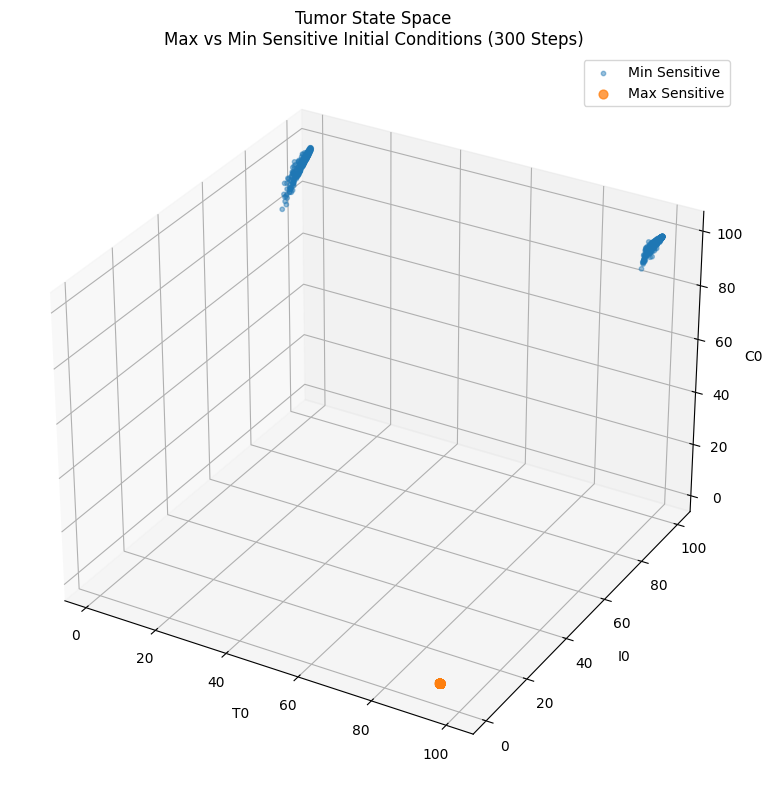

In [19]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


ax.scatter(
    min_data["T0"],
    min_data["I0"],
    min_data["C0"],
    s=10,
    alpha=0.45,
    label=name_output + " Sensitive"
)

ax.scatter(
    max_data["T0"],
    max_data["I0"],
    max_data["C0"],
    s=40,
    alpha=0.75,
    label="Max Sensitive"
)

ax.set_xlabel("T0")
ax.set_ylabel("I0")
ax.set_zlabel("C0")

ax.set_title(
    f"Tumor State Space\nMax vs " + name_output + " Sensitive Initial Conditions (300 Steps)"
)

ax.legend()

plt.tight_layout()
plt.savefig(
    name_output + "_Figure1_3D_StateSpace.png",
    dpi=300
)

plt.show()





## PROJECTION PLOTS


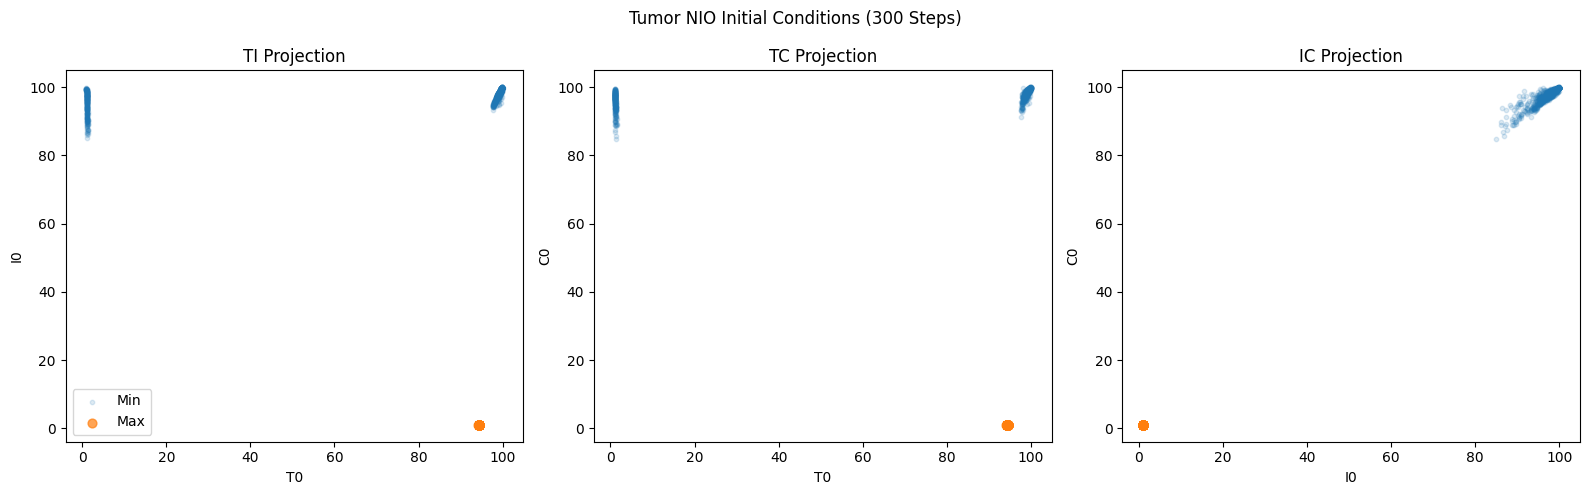

In [20]:


fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


# ------------------------------------------------------------
# XY
# ------------------------------------------------------------

axs[0].scatter(
    min_data["T0"],
    min_data["I0"],
    s=10,
    alpha=0.15,
    label=name_output + ""
)

axs[0].scatter(
    max_data["T0"],
    max_data["I0"],
    s=40,
    alpha=0.7,
    label="Max"
)

axs[0].set_title("TI Projection")
axs[0].set_xlabel("T0")
axs[0].set_ylabel("I0")

# ------------------------------------------------------------
# TC
# ------------------------------------------------------------

axs[1].scatter(
    min_data["T0"],
    min_data["C0"],
    s=10,
    alpha=0.15
)

axs[1].scatter(
    max_data["T0"],
    max_data["C0"],
    s=40,
    alpha=0.7
)

axs[1].set_title("TC Projection")
axs[1].set_xlabel("T0")
axs[1].set_ylabel("C0")

# ------------------------------------------------------------
# IC
# ------------------------------------------------------------

axs[2].scatter(
    min_data["I0"],
    min_data["C0"],
    s=10,
    alpha=0.15
)

axs[2].scatter(
    max_data["I0"],
    max_data["C0"],
    s=40,
    alpha=0.7
)

axs[2].set_title("IC Projection")
axs[2].set_xlabel("I0")
axs[2].set_ylabel("C0")


axs[0].legend()

plt.suptitle(
    f"Tumor NIO Initial Conditions ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure2_ProjectionPlots.png",
    dpi=300
)

plt.show()




## SENSITIVITY DENSITY MAPS

* rho_max - rho_min



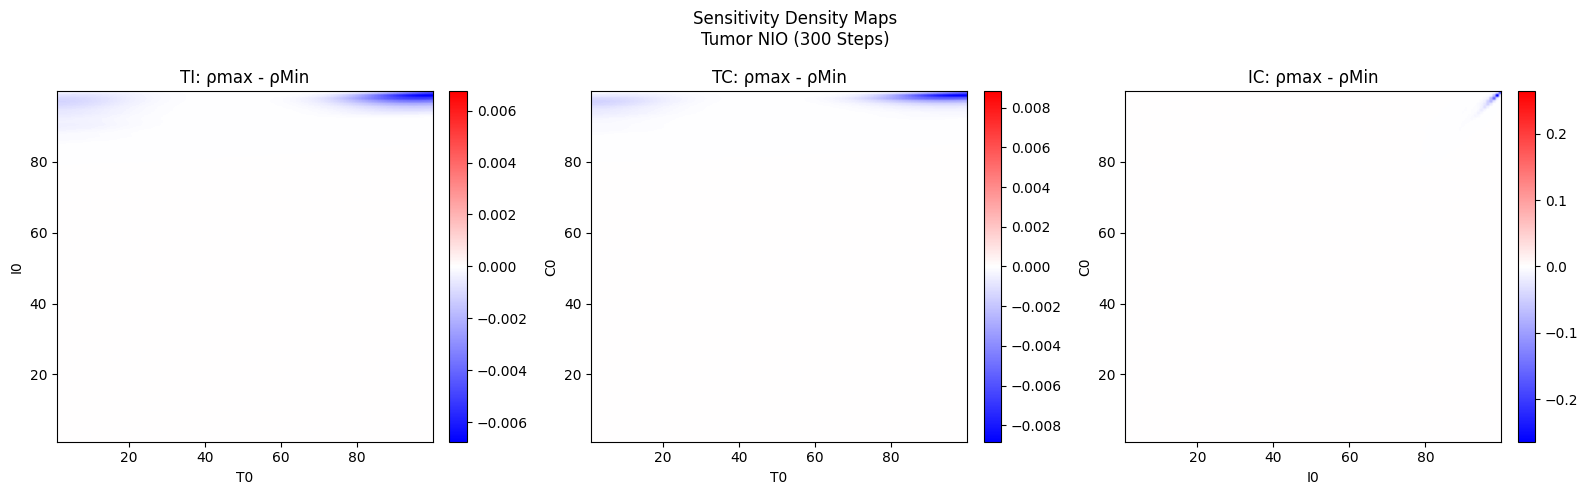

In [21]:

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


pairs = [
    ("T0","I0","TI"),
    ("T0","C0","TC"),
    ("I0","C0","IC")
]


for ax, (a,b,title) in zip(axs,pairs):

    all_a = np.concatenate([
        max_data[a],
        min_data[a]
    ])

    all_b = np.concatenate([
        max_data[b],
        min_data[b]
    ])

    grid_a = np.linspace(
        all_a.min(),
        all_a.max(),
        120
    )

    grid_b = np.linspace(
        all_b.min(),
        all_b.max(),
        120
    )

    A,B = np.meshgrid(
        grid_a,
        grid_b
    )

    kde_max = gaussian_kde(
        np.vstack([
            max_data[a],
            max_data[b]
        ])
    )

    kde_min = gaussian_kde(
        np.vstack([
            min_data[a],
            min_data[b]
        ])
    )

    rho_max = kde_max(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    rho_min = kde_min(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    density_difference = (
        rho_max - rho_min
    )

    vmax = np.abs(
        density_difference
    ).max()

    image = ax.imshow(
        density_difference,
        origin="lower",
        extent=[
            grid_a.min(),
            grid_a.max(),
            grid_b.min(),
            grid_b.max()
        ],
        aspect="auto",
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title(
        f"{title}: ρmax - ρ" + name_output
    )

    ax.set_xlabel(a)
    ax.set_ylabel(b)

    plt.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

 
plt.suptitle(
    f"Sensitivity Density Maps\nTumor NIO ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure3_DensityMaps.png",
    dpi=300
)

plt.show()




## Broken up approach of the previous 




## CREATE XY GRID

* We first create a common coordinate system that both populations will use


In [22]:



x_max = max_data["T0"]
y_max = max_data["I0"]

x_min = min_data["T0"]
y_min = min_data["I0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_y = np.linspace(ymin, ymax, 120)

X_xy, Y_xy = np.meshgrid(
    grid_x,
    grid_y
)


In [23]:

grid_x


array([ 1.0270802 ,  1.85837406,  2.68966793,  3.52096179,  4.35225566,
        5.18354952,  6.01484338,  6.84613725,  7.67743111,  8.50872497,
        9.34001884, 10.1713127 , 11.00260657, 11.83390043, 12.66519429,
       13.49648816, 14.32778202, 15.15907589, 15.99036975, 16.82166361,
       17.65295748, 18.48425134, 19.31554521, 20.14683907, 20.97813293,
       21.8094268 , 22.64072066, 23.47201452, 24.30330839, 25.13460225,
       25.96589612, 26.79718998, 27.62848384, 28.45977771, 29.29107157,
       30.12236544, 30.9536593 , 31.78495316, 32.61624703, 33.44754089,
       34.27883475, 35.11012862, 35.94142248, 36.77271635, 37.60401021,
       38.43530407, 39.26659794, 40.0978918 , 40.92918567, 41.76047953,
       42.59177339, 43.42306726, 44.25436112, 45.08565498, 45.91694885,
       46.74824271, 47.57953658, 48.41083044, 49.2421243 , 50.07341817,
       50.90471203, 51.7360059 , 52.56729976, 53.39859362, 54.22988749,
       55.06118135, 55.89247522, 56.72376908, 57.55506294, 58.38

In [24]:

grid_y


array([ 1.0030704 ,  1.83489309,  2.66671577,  3.49853846,  4.33036114,
        5.16218383,  5.99400651,  6.8258292 ,  7.65765189,  8.48947457,
        9.32129726, 10.15311994, 10.98494263, 11.81676531, 12.648588  ,
       13.48041069, 14.31223337, 15.14405606, 15.97587874, 16.80770143,
       17.63952411, 18.4713468 , 19.30316949, 20.13499217, 20.96681486,
       21.79863754, 22.63046023, 23.46228291, 24.2941056 , 25.12592829,
       25.95775097, 26.78957366, 27.62139634, 28.45321903, 29.28504171,
       30.1168644 , 30.94868709, 31.78050977, 32.61233246, 33.44415514,
       34.27597783, 35.10780051, 35.9396232 , 36.77144589, 37.60326857,
       38.43509126, 39.26691394, 40.09873663, 40.93055931, 41.762382  ,
       42.59420469, 43.42602737, 44.25785006, 45.08967274, 45.92149543,
       46.75331811, 47.5851408 , 48.41696349, 49.24878617, 50.08060886,
       50.91243154, 51.74425423, 52.57607691, 53.4078996 , 54.23972229,
       55.07154497, 55.90336766, 56.73519034, 57.56701303, 58.39


## KDE for Max-Sensitive Points


In [25]:



kde_max_xy = gaussian_kde(
    np.vstack([
        x_max,
        y_max
    ])
)

rho_max_xy = kde_max_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [26]:

kde_max_xy


In [27]:

rho_max_xy


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])


## KDE for Min-Sensitive Points


In [28]:



kde_min_xy = gaussian_kde(
    np.vstack([
        x_min,
        y_min
    ])
)

rho_min_xy = kde_min_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [29]:

# ==================================================
# 
# DIFFERENCE MAP
# ==================================================

rho_diff_xy = (
    rho_max_xy - rho_min_xy
)


In [30]:

rho_diff_xy


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.00103075, -0.00103534, -0.00103589, ..., -0.00515583,
        -0.00509992, -0.00502506],
       [-0.00074838, -0.00076022, -0.00076893, ..., -0.00673964,
        -0.00674948, -0.00672907],
       [-0.00030972, -0.00032347, -0.00033617, ..., -0.00463699,
        -0.00479823, -0.00493994]])

In [31]:

# ==================================================

# XZ PROJECTION
# ==================================================

x_max = max_data["T0"]
z_max = max_data["C0"]

x_min = min_data["T0"]
z_min = min_data["C0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_z = np.linspace(zmin, zmax, 120)

X_xz, Z_xz = np.meshgrid(
    grid_x,
    grid_z
)

kde_max_xz = gaussian_kde(
    np.vstack([
        x_max,
        z_max
    ])
)

rho_max_xz = kde_max_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

kde_min_xz = gaussian_kde(
    np.vstack([
        x_min,
        z_min
    ])
)

rho_min_xz = kde_min_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

rho_diff_xz = (
    rho_max_xz -
    rho_min_xz
)


In [32]:

# ==================================================
# YZ PROJECTION
# ==================================================

y_max = max_data["I0"]
z_max = max_data["C0"]

y_min = min_data["I0"]
z_min = min_data["C0"]

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_y = np.linspace(ymin, ymax, 120)
grid_z = np.linspace(zmin, zmax, 120)

Y_yz, Z_yz = np.meshgrid(
    grid_y,
    grid_z
)

kde_max_yz = gaussian_kde(
    np.vstack([
        y_max,
        z_max
    ])
)

rho_max_yz = kde_max_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

kde_min_yz = gaussian_kde(
    np.vstack([
        y_min,
        z_min
    ])
)

rho_min_yz = kde_min_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

rho_diff_yz = (
    rho_max_yz -
    rho_min_yz
)


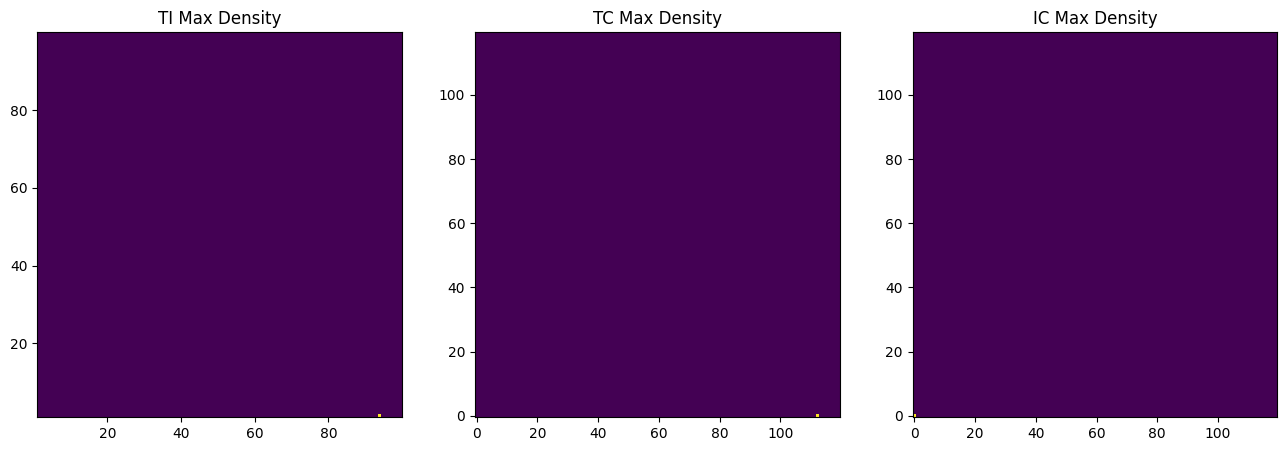

In [33]:

## Where does NIO find highly sensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_max_xy,
    origin="lower",
    extent=[
        grid_x.min(),
        grid_x.max(),
        grid_y.min(),
        grid_y.max()
    ],
    aspect="auto"
)

axs[0].set_title("TI Max Density")

axs[1].imshow(
    rho_max_xz,
    origin="lower",
    aspect="auto"
)

axs[1].set_title("TC Max Density")

axs[2].imshow(
    rho_max_yz,
    origin="lower",
    aspect="auto"
)

axs[2].set_title("IC Max Density")

plt.show()


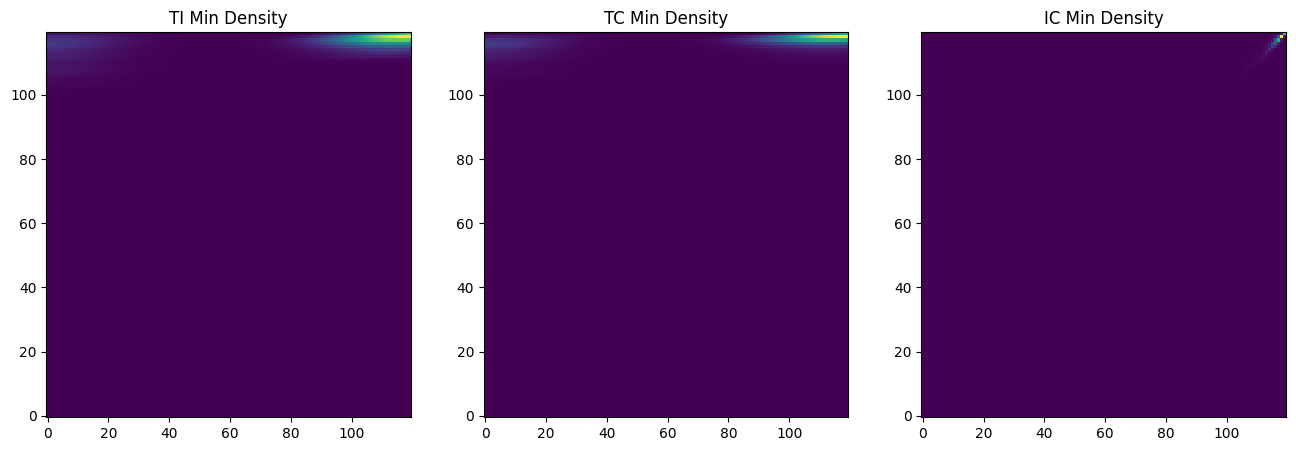

In [34]:

## Where does NIO find insensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(rho_min_xy,origin="lower",aspect="auto")
axs[0].set_title("TI " + name_output + " Density")

axs[1].imshow(rho_min_xz,origin="lower",aspect="auto")
axs[1].set_title("TC " + name_output + " Density")

axs[2].imshow(rho_min_yz,origin="lower",aspect="auto")
axs[2].set_title("IC " + name_output + " Density")

plt.show()


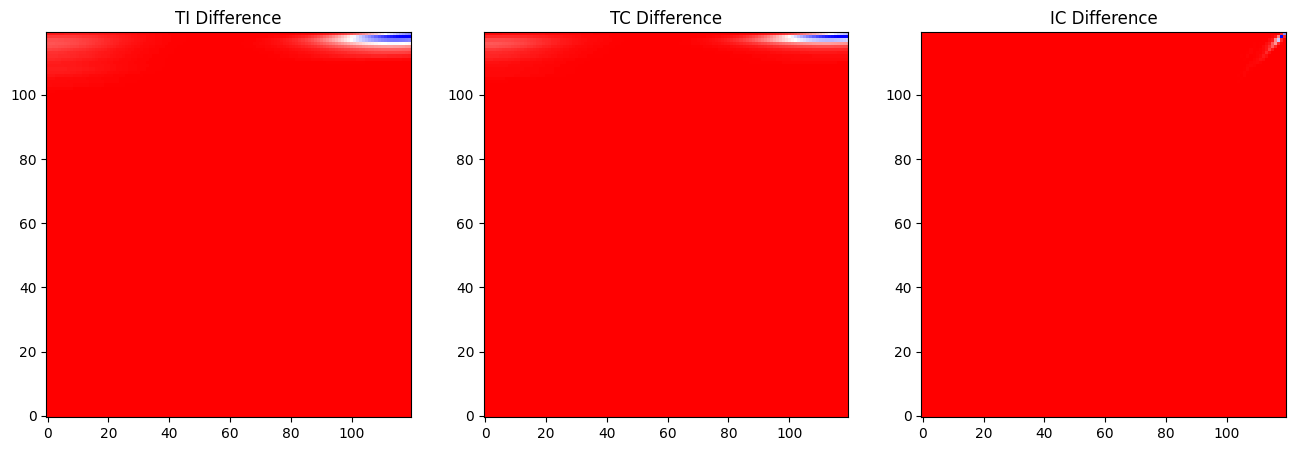

In [35]:

## Where do max-sensitive and min-sensitive regions differ?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_diff_xy,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[0].set_title("TI Difference")

axs[1].imshow(
    rho_diff_xz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[1].set_title("TC Difference")

axs[2].imshow(
    rho_diff_yz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[2].set_title("IC Difference")

plt.show()



## More simplification 


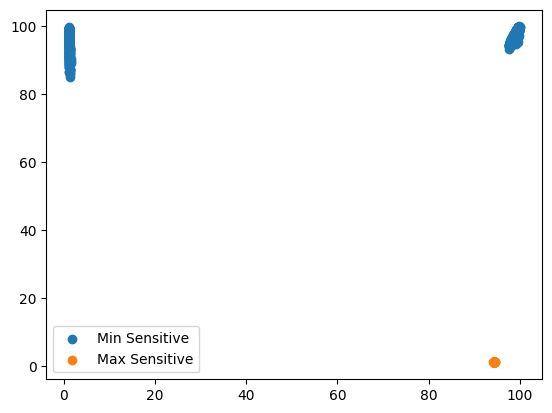

In [36]:


plt.scatter(
    min_data["T0"],
    min_data["I0"],
    label=name_output + " Sensitive"
)

plt.scatter(
    max_data["T0"],
    max_data["I0"],
    label="Max Sensitive"
)


plt.legend()
plt.show()


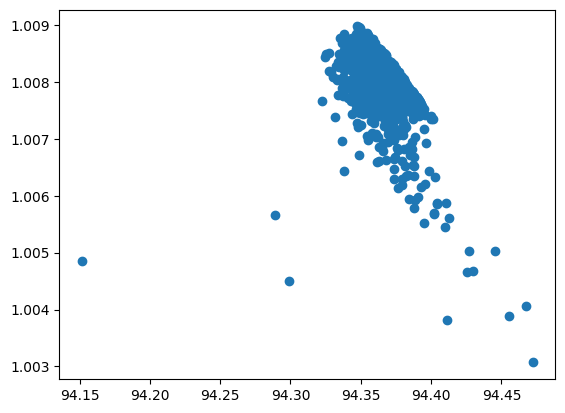

In [37]:

x = max_data["T0"]
y = max_data["I0"]

plt.scatter(x,y)
plt.show()


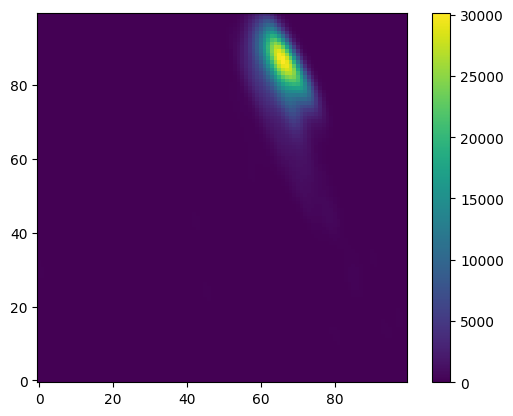

In [38]:

kde = gaussian_kde(
    np.vstack([x,y])
)

grid_x = np.linspace(x.min(),x.max(),100)
grid_y = np.linspace(y.min(),y.max(),100)

X,Y = np.meshgrid(
    grid_x,
    grid_y
)

rho = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
)

rho = rho.reshape(
    X.shape
)

plt.imshow(
    rho,
    origin="lower"
)

plt.colorbar()
plt.show()



## Super Simple Again


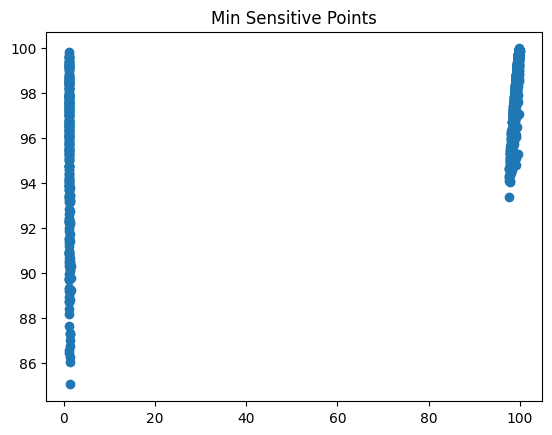

In [39]:

x = min_data["T0"]
y = min_data["I0"]

plt.scatter(x,y)
plt.title(name_output + " Sensitive Points")
plt.show()


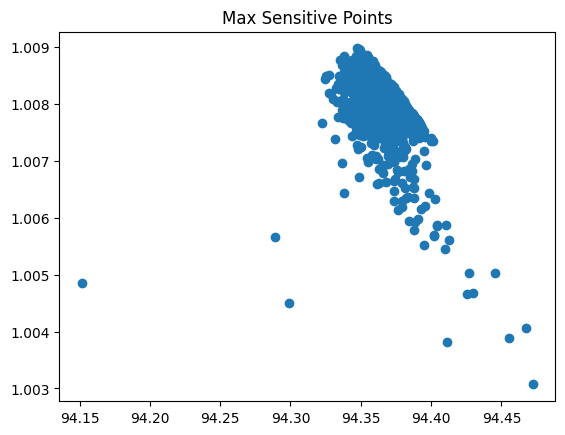

In [40]:

x = max_data["T0"]
y = max_data["I0"]

plt.scatter(x,y)
plt.title("Max Sensitive Points")
plt.show()


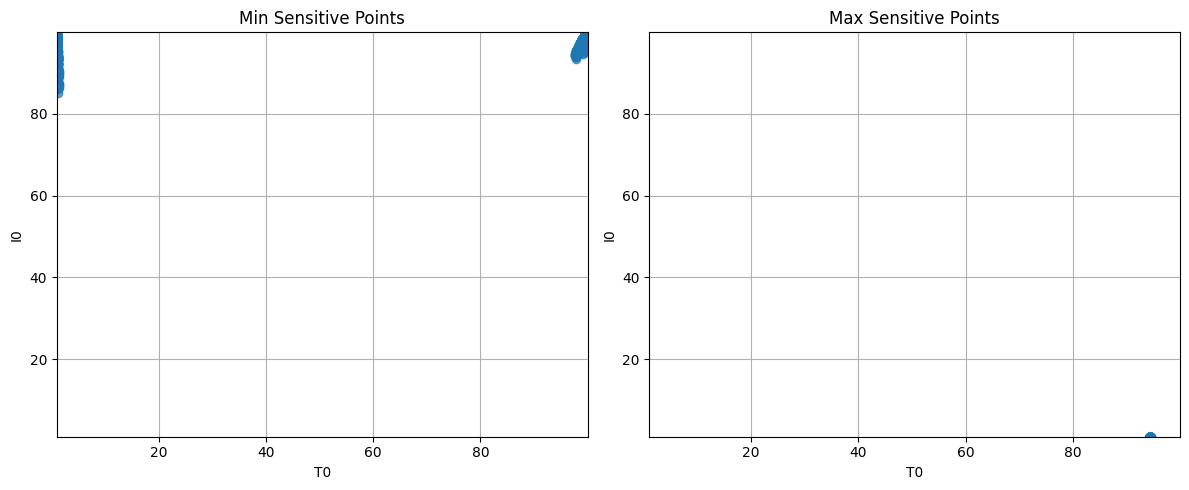

In [41]:

import matplotlib.pyplot as plt

# ---------------------------------------
# Side-by-side comparison
# ---------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Common axis limits
xmin = min(min_data["T0"].min(), max_data["T0"].min())
xmax = max(min_data["T0"].max(), max_data["T0"].max())

ymin = min(min_data["I0"].min(), max_data["I0"].min())
ymax = max(min_data["I0"].max(), max_data["I0"].max())

# ---------------------------------------
# Min-sensitive points
# ---------------------------------------

ax[0].scatter(
    min_data["T0"],
    min_data["I0"],
    alpha=0.7
)

ax[0].set_title(name_output + " Sensitive Points")
ax[0].set_xlabel("T0")
ax[0].set_ylabel("I0")
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)
ax[0].grid(True)

# ---------------------------------------
# Max-sensitive points
# ---------------------------------------

ax[1].scatter(
    max_data["T0"],
    max_data["I0"],
    alpha=0.7
)

ax[1].set_title("Max Sensitive Points")
ax[1].set_xlabel("T0")
ax[1].set_ylabel("I0")
ax[1].set_xlim(xmin, xmax)
ax[1].set_ylim(ymin, ymax)
ax[1].grid(True)

plt.tight_layout()
plt.show()


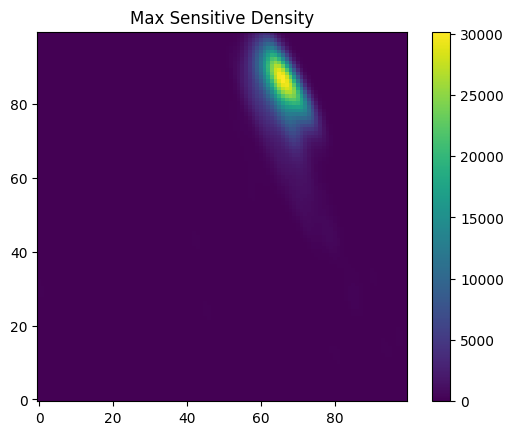

In [42]:

x = max_data["T0"]
y = max_data["I0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_max = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_max,
    origin="lower"
)

plt.colorbar()
plt.title("Max Sensitive Density")
plt.show()


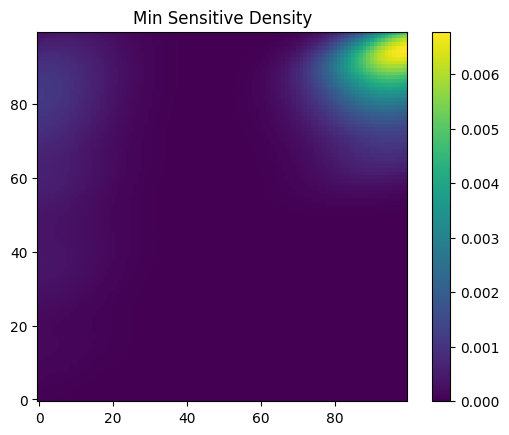

In [43]:

x = min_data["T0"]
y = min_data["I0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_min = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_min,
    origin="lower"
)

plt.colorbar()
plt.title( name_output + " Sensitive Density")
plt.show()


In [44]:

np.vstack([x,y])


array([[ 1.1306393, 99.361465 , 98.103325 , ..., 99.74547  ,  1.1419468,
        99.67051  ],
       [95.29728  , 98.961655 , 96.05984  , ..., 99.01532  , 91.22982  ,
        99.36761  ]])

In [45]:

rho_diff = rho_max - rho_min


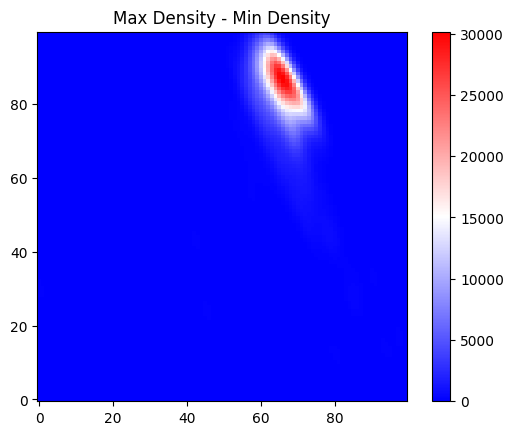

In [46]:

plt.imshow(
    rho_diff,
    origin="lower",
    cmap="bwr"
)

plt.colorbar()
plt.title("Max Density - " + name_output + " Density")
plt.show()



## Generate case 3 - Random data


In [47]:

# ==================================================
# RANDOM BASELINE - TUMOR IMMUNE CYTOKINE MODEL
# ==================================================

import pandas as pd
import numpy as np

N = 1000

random_T = np.random.uniform(
    1.0,
    100.0,
    N
)

random_I = np.random.uniform(
    1.0,
    100.0,
    N
)

random_C = np.random.uniform(
    1.0,
    100.0,
    N
)

random_df = pd.DataFrame({
    "Time_steps": 300,
    "T0"        : random_T,
    "I0"        : random_I,
    "C0"        : random_C
})

random_df.to_csv(
    "random_points.csv",
    index=False
)

print(random_df.head())

print()
print("Saved:")
print("random_points.csv")
print("Number of points:", len(random_df))



   Time_steps         T0         I0         C0
0         300  85.984423  22.079260  19.091260
1         300  44.721803  33.004663  35.546521
2         300  65.122649  35.806584  94.944136
3         300  43.463470  26.167895   2.783258
4         300  22.728541  49.398432  49.169935

Saved:
random_points.csv
Number of points: 1000
